# Multivariate Time Series Forecasting

Most real-world forecasting problems involve **multiple interrelated variables**. Modelling them jointly can capture cross-series dependencies and improve accuracy.

## Univariate vs Multivariate

| Aspect | Univariate | Multivariate |
|--------|-----------|-------------|
| Input | Single series $y_t$ | Vector $\mathbf{y}_t = [y_{1,t}, \ldots, y_{K,t}]^T$ |
| Dependencies | Only temporal | Temporal + cross-series |
| Complexity | Low | High |
| Models | ARIMA, ETS, NBEATS | VAR, VARMA, MTGNN, LSTNet |
| Data needed | Less | More |

            GDP_growth  Consumption_growth  Investment_growth
2008-07-01   -0.006781           -0.008948          -0.017836
2008-10-01   -0.013805           -0.007843          -0.069165
2009-01-01   -0.016612            0.001511          -0.175598
2009-04-01   -0.001851           -0.002196          -0.067561
2009-07-01    0.006862            0.007265           0.020197


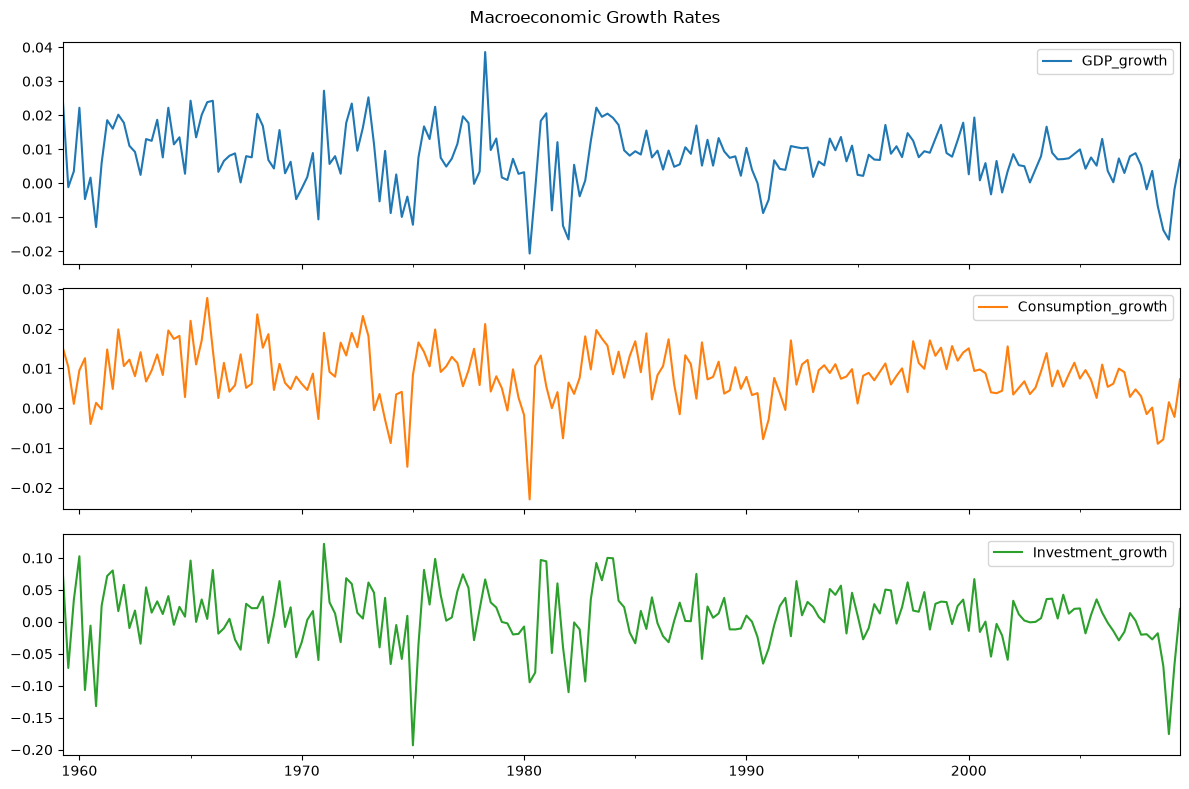

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.statespace.varmax import VARMAX
from statsmodels.tsa.stattools import grangercausalitytests
import warnings
warnings.filterwarnings('ignore')

# Macroeconomic dataset: GDP, consumption, investment
from statsmodels.datasets import macrodata
mdata = macrodata.load_pandas().data
mdata.index = pd.date_range('1959Q1', periods=len(mdata), freq='QS')

# Use log-differences (growth rates) for stationarity
df = mdata[['realgdp', 'realcons', 'realinv']].apply(np.log).diff().dropna()
df.columns = ['GDP_growth', 'Consumption_growth', 'Investment_growth']

print(df.tail())
df.plot(subplots=True, figsize=(12, 8), title='Macroeconomic Growth Rates')
plt.tight_layout()
plt.show()

## Cross-Correlation Analysis

The **Cross-Correlation Function (CCF)** measures how much series $X$ at time $t$ is correlated with series $Y$ at time $t + h$:

$$\rho_{XY}(h) = \frac{\gamma_{XY}(h)}{\sqrt{\gamma_{XX}(0) \cdot \gamma_{YY}(0)}}$$

where $\gamma_{XY}(h) = \mathbb{E}[(X_t - \mu_X)(Y_{t+h} - \mu_Y)]$

A significant $\rho_{XY}(h)$ at lag $h > 0$ suggests $X$ **leads** $Y$ by $h$ periods.

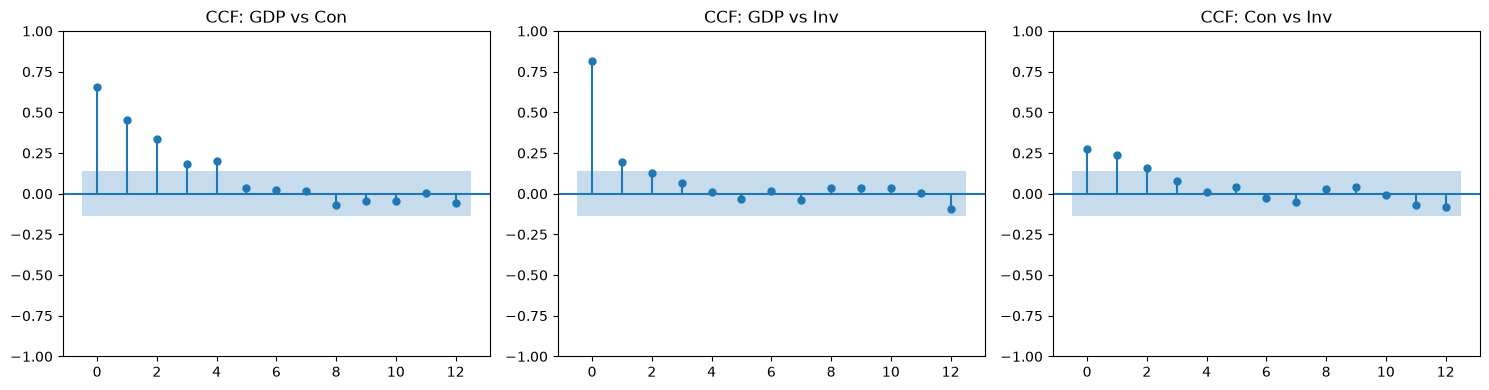

In [2]:
from statsmodels.graphics.tsaplots import plot_ccf

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

pairs = [('GDP_growth', 'Consumption_growth'),
         ('GDP_growth', 'Investment_growth'),
         ('Consumption_growth', 'Investment_growth')]

for ax, (s1, s2) in zip(axes, pairs):
    plot_ccf(df[s1], df[s2], lags=12, ax=ax)
    ax.set_title(f'CCF: {s1[:3]} vs {s2[:3]}')

plt.tight_layout()
plt.show()

## Granger Causality Test

"Does $X$ Granger-cause $Y$?" Does past $X$ improve forecasts of $Y$ beyond using past $Y$ alone?

**Null hypothesis $H_0$:** $X$ does not Granger-cause $Y$

Test via F-test comparing:
- **Restricted:** $Y_t = \sum_{i=1}^{p} \alpha_i Y_{t-i} + \epsilon_t$
- **Unrestricted:** $Y_t = \sum_{i=1}^{p} \alpha_i Y_{t-i} + \sum_{i=1}^{p} \beta_i X_{t-i} + \epsilon_t$

$$F = \frac{(RSS_R - RSS_U)/p}{RSS_U/(n - 2p - 1)} \sim F_{p, n-2p-1}$$

Reject $H_0$ if $F$ is large (or p-value < 0.05) → $X$ Granger-causes $Y$.

**Important:** Granger causality ≠ true causality only predictive causality.

In [3]:
print("Granger Causality Test: Does GDP growth Granger-cause Investment growth?")
print("=" * 70)
gc_result = grangercausalitytests(
    df[['Investment_growth', 'GDP_growth']], maxlag=4, verbose=True
)

Granger Causality Test: Does GDP growth Granger-cause Investment growth?

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=16.0554 , p=0.0001  , df_denom=198, df_num=1
ssr based chi2 test:   chi2=16.2987 , p=0.0001  , df=1
likelihood ratio test: chi2=15.6716 , p=0.0001  , df=1
parameter F test:         F=16.0554 , p=0.0001  , df_denom=198, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=11.2364 , p=0.0000  , df_denom=195, df_num=2
ssr based chi2 test:   chi2=23.0490 , p=0.0000  , df=2
likelihood ratio test: chi2=21.8148 , p=0.0000  , df=2
parameter F test:         F=11.2364 , p=0.0000  , df_denom=195, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=7.6933  , p=0.0001  , df_denom=192, df_num=3
ssr based chi2 test:   chi2=23.9215 , p=0.0000  , df=3
likelihood ratio test: chi2=22.5894 , p=0.0000  , df=3
parameter F test:         F=7.6933  , p=0.0001  , df_denom=192, df_num=3

Granger Causality
nu

## VAR Vector Autoregression

$$\mathbf{y}_t = \mathbf{c} + \mathbf{A}_1 \mathbf{y}_{t-1} + \mathbf{A}_2 \mathbf{y}_{t-2} + \ldots + \mathbf{A}_p \mathbf{y}_{t-p} + \boldsymbol{\epsilon}_t$$

where:
- $\mathbf{y}_t \in \mathbb{R}^K$ = vector of $K$ time series
- $\mathbf{A}_i \in \mathbb{R}^{K \times K}$ = coefficient matrix at lag $i$
- $\boldsymbol{\epsilon}_t \sim \mathcal{N}(\mathbf{0}, \boldsymbol{\Sigma})$ = white noise with covariance $\boldsymbol{\Sigma}$

**Estimation:** OLS equation by equation (efficient since RHS regressors are the same).

**Lag selection:** AIC, BIC, HQIC, FPE balances fit and parsimony.

**Stability condition:** all eigenvalues of companion matrix must lie inside unit circle.

In [4]:
train = df.iloc[:-8]
test  = df.iloc[-8:]

# Fit VAR
model = VAR(train)
lag_sel = model.select_order(maxlags=8)
print("Lag selection criteria:")
print(lag_sel.summary())

best_lag = lag_sel.aic
var_result = model.fit(best_lag)
print(f"\nFitted VAR({best_lag})")
print(var_result.summary())

Lag selection criteria:
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -27.87      -27.82   7.880e-13      -27.85
1     -28.11*     -27.90*  6.219e-13*     -28.02*
2      -28.08      -27.72   6.385e-13      -27.93
3      -28.07      -27.55   6.470e-13      -27.86
4      -28.06      -27.38   6.522e-13      -27.79
5      -28.06      -27.23   6.516e-13      -27.72
6      -28.02      -27.03   6.781e-13      -27.62
7      -28.00      -26.86   6.912e-13      -27.54
8      -28.02      -26.72   6.833e-13      -27.49
-------------------------------------------------

Fitted VAR(1)
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 19, Jun, 2026
Time:                     14:37:55
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -27.801

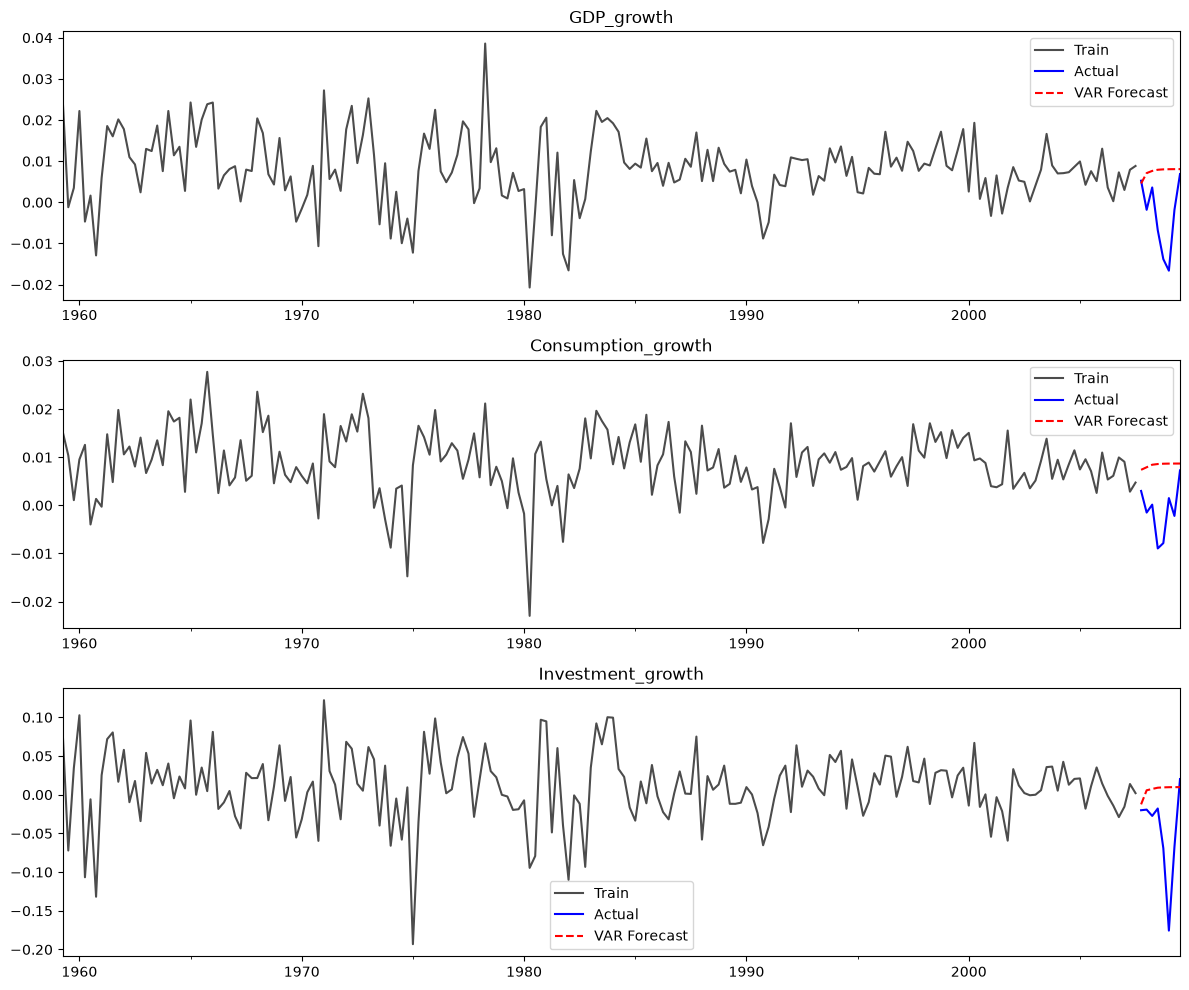

In [5]:
# Forecast
fc = var_result.forecast(y=train.values[-best_lag:], steps=8)
fc_df = pd.DataFrame(fc, index=test.index, columns=df.columns)

fig, axes = plt.subplots(3, 1, figsize=(12, 10))
for i, col in enumerate(df.columns):
    train[col].plot(ax=axes[i], label='Train', color='black', alpha=0.7)
    test[col].plot(ax=axes[i], label='Actual', color='blue')
    fc_df[col].plot(ax=axes[i], label='VAR Forecast', color='red', linestyle='--')
    axes[i].set_title(col)
    axes[i].legend()
plt.tight_layout()
plt.show()

## Impulse Response Functions (IRF)

IRF traces the effect of a **one-standard-deviation shock** to variable $j$ on variable $i$ over time:

$$\Psi_h = \frac{\partial \mathbf{y}_{t+h}}{\partial \boldsymbol{\epsilon}_t}$$

Computed via VMA (Vector Moving Average) representation:
$$\mathbf{y}_t = \sum_{h=0}^{\infty} \Psi_h \boldsymbol{\epsilon}_{t-h}$$

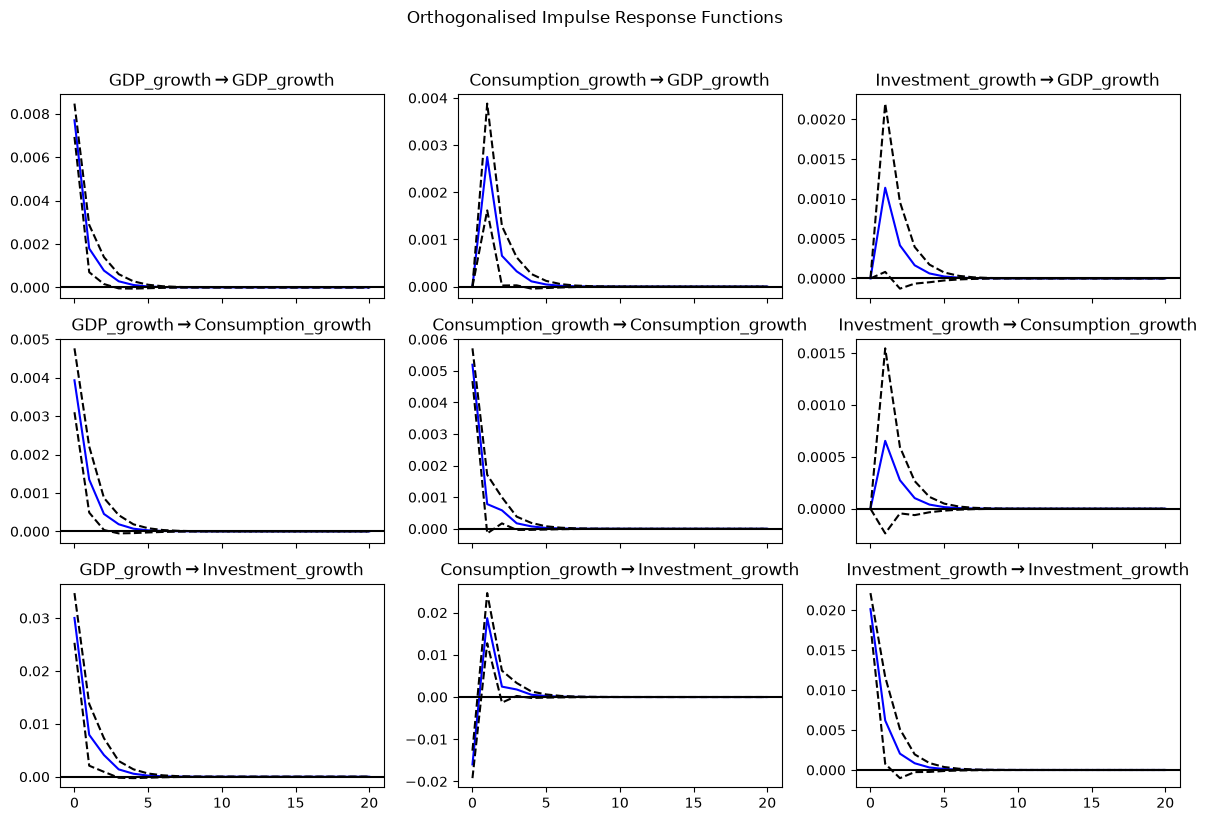

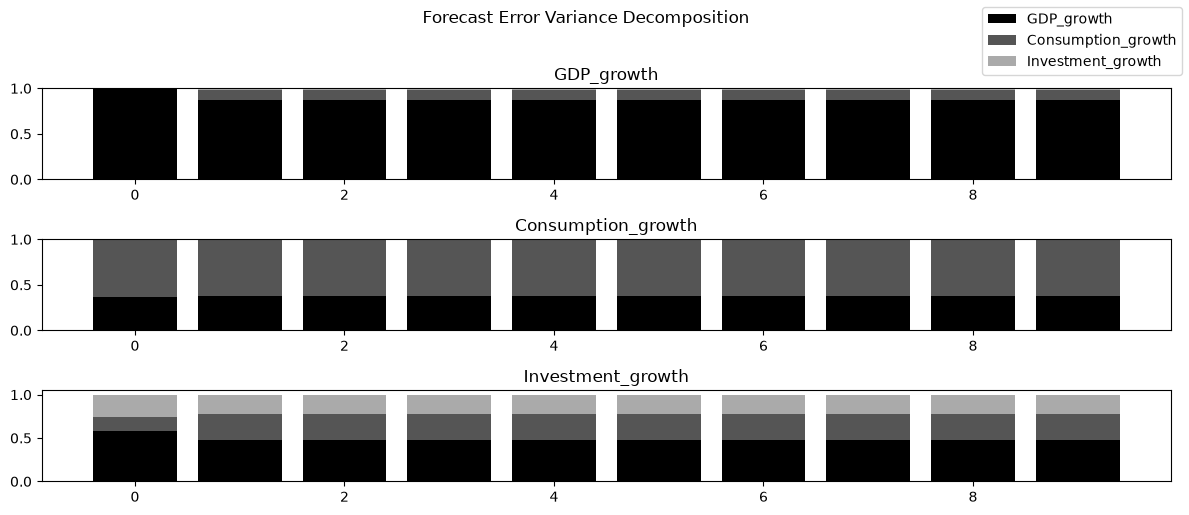

In [6]:
irf = var_result.irf(periods=20)
irf.plot(orth=True, figsize=(12, 8))
plt.suptitle('Orthogonalised Impulse Response Functions', y=1.02)
plt.tight_layout()
plt.show()

# Forecast Error Variance Decomposition
fevd = var_result.fevd(periods=10)
fevd.plot(figsize=(12, 5))
plt.suptitle('Forecast Error Variance Decomposition', y=1.02)
plt.tight_layout()
plt.show()

## VARMA and VARMAX

**VARMA(p,q):** extends VAR with MA terms:
$$\mathbf{y}_t = \mathbf{c} + \sum_{i=1}^{p} \mathbf{A}_i \mathbf{y}_{t-i} + \boldsymbol{\epsilon}_t + \sum_{j=1}^{q} \mathbf{M}_j \boldsymbol{\epsilon}_{t-j}$$

**VARMAX:** adds exogenous regressors $\mathbf{X}_t$:
$$\mathbf{y}_t = \mathbf{c} + \sum_{i=1}^{p} \mathbf{A}_i \mathbf{y}_{t-i} + \mathbf{B} \mathbf{X}_t + \boldsymbol{\epsilon}_t$$

In [7]:
# VARMAX example
varmax = VARMAX(train[['GDP_growth', 'Consumption_growth']],
                order=(1, 1), trend='n').fit(disp=False)
print(varmax.summary())

                                    Statespace Model Results                                    
Dep. Variable:     ['GDP_growth', 'Consumption_growth']   No. Observations:                  194
Model:                                       VARMA(1,1)   Log Likelihood                1404.611
Date:                                  Fri, 19 Jun 2026   AIC                          -2787.221
Time:                                          14:38:02   BIC                          -2751.275
Sample:                                      04-01-1959   HQIC                         -2772.666
                                           - 07-01-2007                                         
Covariance Type:                                    opg                                         
Ljung-Box (L1) (Q):             1.11, 0.40   Jarque-Bera (JB):          10.43, 3.55
Prob(Q):                        0.29, 0.53   Prob(JB):                   0.01, 0.17
Heteroskedasticity (H):         0.27, 0.37   Skew:      

## Deep Learning for Multivariate: LSTNet

**LSTNet** (Long- and Short-term Time-series Network) combines:
1. **CNN** capture short-term local patterns
2. **GRU** capture long-term patterns
3. **Skip-GRU** capture very long-term periodic patterns
4. **AR component** capture scale

Architecture:
$$H_t^C = \text{RELU}(W_c * \mathbf{X}_{t-(k-1):t} + b_c)$$
$$H_t^R = \text{GRU}(H_t^C, H_{t-1}^R)$$
$$\hat{Y}_t = W H_t^R + W^S H_{t-p}^S + W^A \mathbf{X}_t + b$$

In [8]:
import torch
import torch.nn as nn

class LSTNet(nn.Module):
    def __init__(self, num_series, seq_len, cnn_kernel=6, rnn_hidden=64,
                 skip=24, skip_hidden=8, pred_len=1, dropout=0.2):
        super().__init__()
        self.P    = seq_len
        self.m    = num_series
        self.skip = skip
        self.hidR = rnn_hidden
        self.hidS = skip_hidden
        self.pt   = (self.P - cnn_kernel) // skip
        
        self.conv1  = nn.Conv2d(1, rnn_hidden, kernel_size=(cnn_kernel, num_series))
        self.gru    = nn.GRU(rnn_hidden, rnn_hidden, batch_first=True)
        self.gru_s  = nn.GRU(rnn_hidden, skip_hidden, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.linear  = nn.Linear(rnn_hidden, num_series * pred_len)
        self.ar      = nn.Linear(seq_len, pred_len)
    
    def forward(self, x):
        # x: (batch, seq_len, num_series)
        batch = x.size(0)
        
        # CNN
        c = x.unsqueeze(1)           # (B, 1, T, K)
        c = self.conv1(c)            # (B, hidR, T', 1)
        c = torch.relu(c).squeeze(3) # (B, hidR, T')
        c = self.dropout(c)
        
        # GRU
        r, _ = self.gru(c.permute(0, 2, 1))   # (B, T', hidR)
        r = self.dropout(r[:, -1, :])           # (B, hidR)
        
        # Linear + AR
        ar = self.ar(x.permute(0, 2, 1)).squeeze(-1)  # AR (linear) component per series
        out = self.linear(r).view(batch, self.m, -1).squeeze(-1)
        return out + ar  # combine nonlinear (CNN+GRU) and linear AR parts

model = LSTNet(num_series=3, seq_len=24)
x_dummy = torch.randn(8, 24, 3)
print(f"LSTNet output shape: {model(x_dummy).shape}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

LSTNet output shape: torch.Size([8, 3])
Parameters: 28,172


## Covariates in Multivariate Forecasting

| Covariate Type | Description | Example |
|---------------|-------------|--------|
| **Static** | Fixed, time-invariant per series | Product category, store ID |
| **Past-observed** | Known only up to present | Sales, price, weather actual |
| **Future-known** | Known ahead of time | Planned promotions, holidays, day of week |

TFT, DeepAR, and NeuralForecast models handle all three covariate types.

In [9]:
try:
    from neuralforecast import NeuralForecast
    from neuralforecast.models import NHITS, PatchTST
    from neuralforecast.losses.pytorch import MAE
    print("NeuralForecast available for multivariate forecasting")
    print("Supported multivariate models: NHITS, PatchTST, iTransformer, TimesNet, etc.")
except ImportError:
    print("Install: pip install neuralforecast")

Install: pip install neuralforecast


## Channel Independence vs Mixing

A key design decision in multivariate deep learning forecasters:

**Channel Independence (CI):** treat each series independently, share parameters
- Used by: PatchTST, DLinear
- Pro: simpler, avoids spurious cross-series correlations
- Con: ignores genuine cross-series dependencies

**Channel Mixing (CM):** model cross-series interactions explicitly
- Used by: Crossformer, iTransformer, MTGNN
- Pro: captures genuine dependencies
- Con: more parameters, risk of overfitting

**Empirical finding (2023):** CI often beats CM on standard benchmarks cross-series dependencies may be task-specific.

---

## Additional Learning Resources

### Papers
- **LSTNet** Lai et al. (2018): https://arxiv.org/abs/1703.07015
- **MTGNN** Wu et al. (2020) graph network for MTS: https://arxiv.org/abs/2005.11650
- **iTransformer** Liu et al. (2024): https://arxiv.org/abs/2310.06625
- **Are Transformers Effective for Time Series?** Zeng et al. (2023): https://arxiv.org/abs/2205.13504
- **Crossformer** Zhang & Yan (2023): https://arxiv.org/abs/2108.00154

### Libraries
- NeuralForecast: https://nixtlaverse.nixtla.io/neuralforecast/
- GluonTS multivariate: https://ts.gluon.ai/stable/tutorials/multivariate.html
- pytorch-forecasting TFT: https://pytorch-forecasting.readthedocs.io/

### Courses
- Forecasting: Principles and Practice (Ch. 11 VAR): https://otexts.com/fpp3/VAR.html
- Applied Time Series for Finance: https://www.coursera.org/learn/financial-engineering-1